# Реализация табличного Q-Learning

В этом уроке мы разберем на практике простой алгоритм обучения табличной Q-функции на примере задачи Frozen Lake.

### Загрузка библиотек

In [2]:
import numpy as np


import gymnasium as gym

import matplotlib.pyplot as plt
%matplotlib inline

### Создание игровой среды
Создадим симулятор Frozen Lake.

In [15]:
env = gym.make('FrozenLake-v1', is_slippery=False,
    render_mode="ansi")


NUM_STATES = env.observation_space.n
NUM_ACTIONS = env.action_space.n

print('States: {}'.format(NUM_STATES))
print('Actions: {}'.format(NUM_ACTIONS))

States: 16
Actions: 4


### Параметры обучения

* `lr` - скорость обучения (в теории это был параметр `alpha`)
* `gamma` - параметр дисконтирования
* `NUM_EPISODES` - сколько всего эпизодов игры будем осуществлять
* `MAX_STEPS` - максимальное количесвто шагов в рамках одного эпизода. Эпизод может закончиться и раньше. Это ограничение нужно, если агент зашёл в какой-то тупик и там застрял. Или для бесконечных игр/симуляций.

In [16]:
lr = 0.8 # learning rate
gamma = 0.95 # параметр дисконтирования

NUM_EPISODES = 50 # число эпизодов для обучения
MAX_STEPS = 100 # максимальное число шагов в эпизоде

### Обучение Q-функции

Во время обучения удобно следить за разными характеристиками. В данном случае будем собирать данные о длине траектории (как далеко удаётся дойти нашему агенту) по эпизодам и суммарную награду по эпизодам. От эпизода к эпизоду наш агент должен становиться всё лучше и лучше.

Создаём Q-функцию (таблицу) и инициализируем её случайными числами. В нашем простом Q-Learning'е во время игры мы всегда будем использовать детерминированную политику (выбор действия строго по Q-функции). Поэтому важно инициализировать Q-функцию так, чтобы агент не застревал в циклах и всё же мог когди-нибудь дойти до цели. В нашем случае, главное -- не занулять те значения Q-функции, которые потенциально могут привести нас к цели (например, нельзя всю таблицу инициализировать нулями). У такой проблемы есть и более элегантное решение, которое мы рассмотрим в других уроках.

Далее идёт цикл по эпизодам и цикл по шагам внутри эпизода.

В начале каждого эпизода переходим на нулевое состояние `env.reset()`

Один шаг обучения состоит в следующем:

* Выбор действия `a` по политике с использованием текущей функции Q
* Сообщение действия среде, получение следующего состояния `s1`, награды `r` и сигнала о конце эпизода `done`.
* Вычисление целевого (нового) значения `Q_target` (по уравнению Беллмана)
* Плавное обновление Q функции для старого состояния `s` и действия `a` (с использование learning rate)

В конце каждого эпизода смотрим на суммарную накопленную награду.

In [17]:
pathLenList = [] # длины траекторий по эпизодам
totalRewardList = [] # суммарные награды по эпизодам

# Инициализация Q-функции (таблицы)
Q = np.random.rand(NUM_STATES, NUM_ACTIONS)

for i in range(NUM_EPISODES):

    s, info = env.reset()

    totalReward = 0
    step = 0

    while step < MAX_STEPS:
        step += 1

        # Выбор действия по текущей политике
        a = np.argmax(Q[s,:])

        # Сделать шаг
        s1, r, terminated, truncated, _ = env.step(a)

        # Новое (целевое) значение Q-функции
        if terminated:
            Q_target = r
        else:
            Q_target = r + gamma * np.max(Q[s1,:])

        # Обновление Q-функции
        Q[s,a] = (1-lr) * Q[s,a] + lr * Q_target

        totalReward += r
        s = s1

        # Если конец эпизода
        if terminated or truncated:
            break

    pathLenList.append(step)
    totalRewardList.append(totalReward)
    print('Episode {}: Total reward = {}'.format(i, totalReward))

Episode 0: Total reward = 0
Episode 1: Total reward = 0
Episode 2: Total reward = 0
Episode 3: Total reward = 0
Episode 4: Total reward = 0
Episode 5: Total reward = 0
Episode 6: Total reward = 1
Episode 7: Total reward = 1
Episode 8: Total reward = 1
Episode 9: Total reward = 1
Episode 10: Total reward = 1
Episode 11: Total reward = 1
Episode 12: Total reward = 1
Episode 13: Total reward = 1
Episode 14: Total reward = 1
Episode 15: Total reward = 1
Episode 16: Total reward = 1
Episode 17: Total reward = 1
Episode 18: Total reward = 1
Episode 19: Total reward = 1
Episode 20: Total reward = 1
Episode 21: Total reward = 1
Episode 22: Total reward = 1
Episode 23: Total reward = 1
Episode 24: Total reward = 1
Episode 25: Total reward = 1
Episode 26: Total reward = 1
Episode 27: Total reward = 1
Episode 28: Total reward = 1
Episode 29: Total reward = 1
Episode 30: Total reward = 1
Episode 31: Total reward = 1
Episode 32: Total reward = 1
Episode 33: Total reward = 1
Episode 34: Total reward

Посмотрим на то, как выглядит обученная оптимальная Q-функция

In [18]:
print(Q)

[[0.24328315 0.77378094 0.13825041 0.24192677]
 [0.41904415 0.27050723 0.442537   0.73831135]
 [0.38189745 0.51588178 0.47842865 0.47224503]
 [0.88673789 0.88060355 0.68795885 0.4947335 ]
 [0.25329259 0.81450625 0.1117775  0.25269582]
 [0.03950292 0.61163763 0.25016978 0.61625434]
 [0.12892008 0.27736296 0.12363827 0.12765976]
 [0.05946615 0.59237244 0.51425566 0.98503816]
 [0.26346643 0.09012751 0.857375   0.10608315]
 [0.27653031 0.9025     0.27110456 0.07908178]
 [0.02713291 0.79454281 0.06490454 0.27389758]
 [0.69868349 0.12433763 0.24704323 0.03126323]
 [0.87846664 0.46223552 0.4391527  0.64136261]
 [0.23573361 0.06643777 0.95       0.29306683]
 [0.28917227 0.28072786 1.         0.27968228]
 [0.52187671 0.64525546 0.10868662 0.66542486]]


Посмотрим на историю длин траекторий. Видно, что сначала агент долго гулял и не мог найти цель (на ранних эпизодах). Потом постепенно он научился находить цель за минимальное количество шагов.

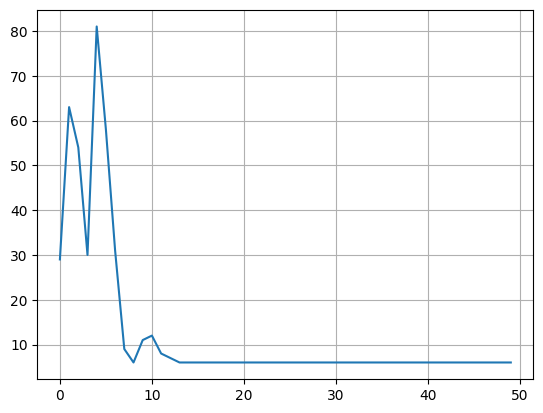

In [19]:
plt.plot(pathLenList)
plt.grid()

То же самое видно на графике суммарных наград по эпизодам. На ранних эпизодах награда 0 (это значит, что агент либо падал в яму, либо так и не смог завершить эпизод за `MAX_STEPS` шагов). А далее награда 1, то есть агент стал доходить до цели.

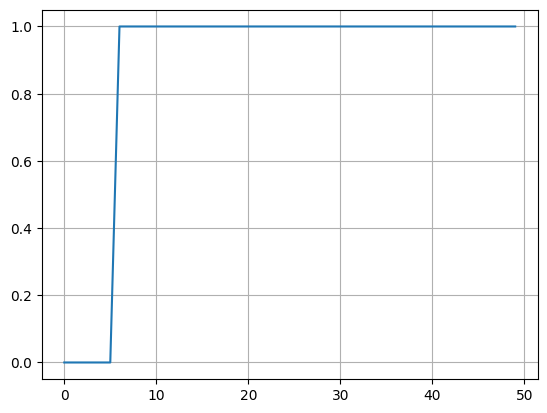

In [20]:
plt.plot(totalRewardList)
plt.grid()

### Запуск симуляции

Запустим симуляцию для Frozen Lake так же, как мы делали до этого. Будем использовать стратегию, основанную на обученной оптимальной Q-функции.

In [21]:
totalReward = 0
s, info = env.reset()

for _ in range(100):
    #print(env.render())
    env.render()
    a = np.argmax(Q[s,:]) # выбираем оптимальное действие
    s, r, terminated, truncated, _ = env.step(a)
    totalReward += r
    print(env.render())
    if terminated or truncated:
        env.render()
        print('Final reward = {}'.format(r))
        break

env.close()
print('Total reward = {}'.format(totalReward))

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

Final reward = 1
Total reward = 1


In [22]:
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.4 MB/s eta 0:00:00


In [30]:
import gymnasium as gym



env = gym.make('CarRacing-v3', render_mode="rgb_array")

state_shape = env.observation_space.shape # (96, 96, 3)
ACTION_SPACE = env.action_space
ACTION_SHAPE = ACTION_SPACE.shape
ACTION_LOW = ACTION_SPACE.low
ACTION_HIGH = ACTION_SPACE.high
action_dim = env.action_space.shape[0] # 3

print(f"Состояние: {state_shape}")
print(f"Размерность действия: {action_dim}")
env.close()

Состояние: (96, 96, 3)
Размерность действия: 3


In [ ]:
lr = 0.8 # learning rate
gamma = 0.95 # параметр дисконтирования

NUM_EPISODES = 50 # число эпизодов для обучения
MAX_STEPS = 100 # максимальное число шагов в эпизоде

In [32]:
!pip install stable-baselines3[extra] gymnasium[box2d]
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np


# Создаем среду
env = gym.make('CarRacing-v3', render_mode='rgb_array')
env = DummyVecEnv([lambda: env])  # Векторизованная среда для Stable-Baselines

# Создаем модель PPO (Proximal Policy Optimization)
model = PPO(
    'CnnPolicy',  # Сверточная нейросеть для изображений
    env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=512,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    tensorboard_log="./carracing_tensorboard/"
)

print("Начинаем обучение...")
print("=" * 50)

# Обучаем
model.learn(total_timesteps=50000)  # 50 тысяч шагов

# Сохраняем модель
model.save("carracing_ppo_model")

print("\nОбучение завершено!")
print("=" * 50)

# Оцениваем обученную модель
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)
print(f"Средняя награда после обучения: {mean_reward:.2f} +/- {std_reward:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.0 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env in a VecTransposeImage.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Начинаем обучение...
Logging to ./carracing_tensorboard/PPO_1
----------------------------
| time/              |     |
|    fps             | 108 |
|    iterations      | 1   |
|    time_elapsed    | 4   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 62          |
|    iterations           | 2           |
|    time_elapsed         | 16          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.009222118 |
|    clip_fraction        | 0.0699      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.25       |
|    explained_variance   | 0.00437     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.261       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00979    |
|    std                  | 0.995       |
|    value_loss      

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Средняя награда после обучения: -82.96 +/- 1.20


In [43]:
# Монтируем Google Диск
from google.colab import drive
drive.mount('/content/drive')

# Создаем папку на Google Диске для видео
import os
video_folder = '/content/drive/MyDrive/ColabNotebooks/gym_videos'
os.makedirs(video_folder, exist_ok=True)
print(f"Видео будут сохраняться в: {video_folder}")

Mounted at /content/drive
Видео будут сохраняться в: /content/drive/MyDrive/ColabNotebooks/gym_videos


In [54]:
from gymnasium.wrappers import RecordVideo
import gymnasium as gym
import ale_py
from IPython.display import Video, display as ipy_display
import os
from datetime import datetime

# Регистрируем Atari
gym.register_envs(ale_py)

# Создаем среду (ВАЖНО: render_mode='rgb_array')
env = gym.make('CarRacing-v3', render_mode='rgb_array')

date_str = datetime.now().strftime("%Y%m%d_%H%M")
model_name = f'carracing_model_{date_str}.pt'

video_folder = f'/content/drive/MyDrive/ColabNotebooks/gym_videos/carracing{date_str}'
os.makedirs(video_folder, exist_ok=True)
print(f"Видео будут сохраняться на Google Диск: {video_folder}")

# Оборачиваем в RecordVideo (аналог Monitor)
env = RecordVideo(
    env,
    video_folder=video_folder,  # папка для видео
    episode_trigger=lambda episode_id: True,  # записывать все эпизоды
    name_prefix='CarRacing_recording'
)

# Сброс среды - В Гимназиуме reset() возвращает (observation, info)
obs, info = env.reset()
totalReward = 0

for step in range(1000):
    # В Гимназиуме render() не всегда нужен - кадры захватываются автоматически
    # env_sim.render()  # МОЖНО УБРАТЬ, RecordVideo сам захватывает кадры

    #  действие модели
    action, _ = model.predict(obs, deterministic=True)

    # Шаг среды - В Гимназиуме step() возвращает 5 значений!
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    # Объединяем флаги окончания
    done = terminated or truncated

    #totalReward += r

    # Выводим ненулевые награды
    #if r != 0:
        #print(f'New reward = {r} (шаг {step})')

    # Проверка окончания эпизода
    if done:
        print(f'Эпизод закончен на шаге {total_reward:.2f}')
        break

# Важно! Закрываем среду для сохранения видео
env.close()

print(f'Total reward = {totalReward}')

# Проверяем, что видео сохранилось
import glob
videos = sorted(glob.glob(os.path.join(video_folder, '*.mp4')), key=os.path.getmtime)
if videos:
    old_name = videos[-1]
    new_name = os.path.join(video_folder, model_name.replace('.pt', '.mp4'))
    os.rename(old_name, new_name)
    print(f"Видео сохранено как: {new_name}")

print(f'Total reward = {totalReward}')

# Проверяем видео (с новым именем)
if videos:
    ipy_display(Video(new_name, embed=True, width=600))

Видео будут сохраняться на Google Диск: /content/drive/MyDrive/ColabNotebooks/gym_videos/carracing20260226_1452


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/ColabNotebooks/gym_videos/carracing20260226_1452 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Эпизод закончен на шаге -489.49
Total reward = 0
Видео сохранено как: /content/drive/MyDrive/ColabNotebooks/gym_videos/carracing20260226_1452/carracing_model_20260226_1452.mp4
Total reward = 0


In [45]:
def show_video(video_path=None, folder=None):
    """
    Универсальная функция для просмотра видео в Colab

    Параметры:
    - video_path: конкретный путь к видео файлу
    - folder: папка для поиска видео (покажет первое найденное)
    """
    import glob
    import io
    import base64
    from IPython.display import HTML
    from IPython import display as ipythondisplay
    import os

    # Определяем, какое видео показывать
    if video_path and os.path.exists(video_path):
        mp4list = [video_path]
    elif folder:
        mp4list = glob.glob(os.path.join(folder, '*.mp4'))
    else:
        # По умолчанию ищем в стандартных папках
        mp4list = []
        for search_folder in ['./', './video', './pong_video', './pong_frames']:
            mp4list.extend(glob.glob(os.path.join(search_folder, '*.mp4')))

        # Ищем на Google Диске
        drive_folder = '/content/drive/MyDrive/ColabNotebooks/gym_videos'
        if os.path.exists(drive_folder):
            mp4list.extend(glob.glob(os.path.join(drive_folder, '*.mp4')))

    if len(mp4list) > 0:
        # Берем первое видео или самое новое
        mp4 = sorted(mp4list, key=os.path.getmtime)[-1]
        print(f"Показываем видео: {mp4}")
        print(f"   Размер: {os.path.getsize(mp4) / 1024:.1f} KB")
        print(f"   Создано: {time.ctime(os.path.getmtime(mp4))}")

        # Способ 1: через Video (проще)
        try:
            from IPython.display import Video
            return Video(mp4, embed=True, width=600)
        except:
            pass

        # Способ 2: через base64 (надежнее)
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data='''<video alt="test" autoplay
            loop controls style="height: 400px;">
            <source src="data:video/mp4;base64,{0}" type="video/mp4" />
            </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Видео не найдено!")
        print("   Искали в:")
        if folder:
            print(f"   - {folder}")
        print("   - ./video/*.mp4")
        print("   - ./pong_video/*.mp4")
        print("   - /content/drive/MyDrive/ColabNotebooks/gym_videos/*.mp4")

In [55]:
from IPython.display import Video, display as ipy_display
import time
show_video()

Показываем видео: /content/drive/MyDrive/ColabNotebooks/gym_videos/CarRacing_recording-episode-0.mp4
   Размер: 336.5 KB
   Создано: Wed Feb 25 14:30:42 2026


In [57]:
from IPython.display import Video
import glob
import os

video_folder = './carracing_videos'
videos = sorted(glob.glob(os.path.join(video_folder, '*.mp4')), key=os.path.getmtime)

if videos:
    latest_video = videos[-1]
    print(f"Видео: {latest_video}")
    Video(latest_video, embed=True, width=600)
else:
    print("Видео не найдено")

Видео: ./carracing_videos/CarRacing_recording-episode-0.mp4
